# Supplementary Figure — Core Dataset Composition

Standalone companion to `GEMVAP_Pipeline_gnomAD4_part1_train_calibrate.ipynb`.

It does not touch the train/test split, model fits, or calibration. It only
re-reads the **core dataset** — the raw variant table at `data_path` in
`config_gnomad4.yaml`, exactly as loaded by `DataProcessor` before any
missense filtering, training-cohort exclusion, or de novo/test-set logic is
applied — and reports how many variants fall into each label class:

- **Pathogenic** — flagged in a pathogenic source database (HGMD, UMD, FRANKEN,
  MUTDB, PARIS, GENT) and not in gnomAD.
- **Control** — observed in gnomAD (exomes or genomes) and not in a pathogenic
  source database.
- **Intersection** — flagged in *both* a pathogenic database and gnomAD
  (contradictory evidence; excluded from training in the main pipeline).
- **Others** — in neither a pathogenic nor a control database (unlabeled).
- **Total** — all four classes summed = row count of the (sub)dataset.

Two breakdowns are produced:

1. **All consequence types** in the core dataset.
2. **Missense-only** subset (`Consequence == 'missense_variant'`, same
   definition as `DataProcessor.is_mis`) — the class GEMVAP is trained on.

Outputs are written to `OUTPUT_DIR` (same directory as Part 1):
`Supplementary_Table_CoreDataset.csv` and `Supplementary_Table_CoreDataset.png`.

**Run with working directory set to `gemvap_clean_pipeline/`.**

In [1]:
import os, sys
from pathlib import Path

import pandas as pd

sys.path.append("scripts")
from pipeline_log import step, inputs, info, action, result, summary_table, subsection

step(1, "Environment & configuration setup")

cwd = Path(os.getcwd())
if not (cwd / "gemvap_pipeline").is_dir():
    raise RuntimeError(
        f"Working directory is '{cwd}'.\n"
        "Please open / run this notebook from the gemvap_clean_pipeline/ folder."
    )

import yaml
_cfg = yaml.safe_load(open("config_gnomad4.yaml"))
DATA_PATH  = _cfg["data_path"]
SEED       = int(_cfg["seed"])
OUTPUT_DIR = Path(_cfg["output_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

inputs([(DATA_PATH, "core dataset -- raw FBN1 variant table, pathogenic + control + unlabeled")])
result(f"Config loaded. data_path={DATA_PATH}  seed={SEED}  output_dir={OUTPUT_DIR}")

  Step 1 — Environment & configuration setup
  Inputs:
    - data/raw/FBN1_tableS1_allmissense_gnomad4.tsv  (core dataset -- raw FBN1 variant table, pathogenic + control + unlabeled)
  -> Config loaded. data_path=data/raw/FBN1_tableS1_allmissense_gnomad4.tsv  seed=42  output_dir=output\gemvap_notebook_gnomad4


In [2]:
step(2, "Load the core dataset")
info("The core dataset is the raw table as read by DataProcessor -- before missense\n"
     "filtering, training-cohort exclusion, or the de novo/test-set split applied in\n"
     "Part 1. is_case / is_ctrl / is_inte come directly from DataProcessor.create_filters().")

from gemvap_pipeline.data import load_processor

action(f"Reading {DATA_PATH}")
dp = load_processor(DATA_PATH, seed=SEED)
result(f"Core dataset loaded: {len(dp.data)} rows")

  Step 2 — Load the core dataset
    [i] The core dataset is the raw table as read by DataProcessor -- before missense
    [i] filtering, training-cohort exclusion, or the de novo/test-set split applied in
    [i] Part 1. is_case / is_ctrl / is_inte come directly from DataProcessor.create_filters().


  >> Reading data/raw/FBN1_tableS1_allmissense_gnomad4.tsv


  -> Core dataset loaded: 21211 rows


In [3]:
step(3, "Classify variants: pathogenic / control / intersection / others")
info("Pathogenic  = in a pathogenic source DB (HGMD/UMD/FRANKEN/MUTDB/PARIS/GENT), not in gnomAD.\n"
     "Control     = in gnomAD (exomes/genomes), not in a pathogenic source DB.\n"
     "Intersection= in BOTH a pathogenic source DB and gnomAD (contradictory labels).\n"
     "Others      = in neither -- unlabeled.")

def composition_table(mask: pd.Series, label: str) -> pd.DataFrame:
    n_path = int((dp.is_case & mask).sum())
    n_ctrl = int((dp.is_ctrl & mask).sum())
    n_inte = int((dp.is_inte & mask).sum())
    n_total = int(mask.sum())
    n_other = n_total - n_path - n_ctrl - n_inte
    rows = [
        ("Pathogenic", n_path),
        ("Control", n_ctrl),
        ("Intersection", n_inte),
        ("Others", n_other),
        ("Total", n_total),
    ]
    df_out = pd.DataFrame(rows, columns=["Category", label])
    return df_out.set_index("Category")

all_mask = pd.Series(True, index=dp.data.index)
mis_mask = dp.is_mis

table_all = composition_table(all_mask, "N (all consequences)")
table_mis = composition_table(mis_mask, "N (missense only)")

action("Counting variants by class -- all consequence types")
summary_table(
    "Core Dataset Composition -- All Consequence Types",
    ["Category", "N"],
    [(idx, int(row.iloc[0])) for idx, row in table_all.iterrows()],
)

action("Counting variants by class -- missense only")
summary_table(
    "Core Dataset Composition -- Missense Only",
    ["Category", "N"],
    [(idx, int(row.iloc[0])) for idx, row in table_mis.iterrows()],
)

combined = table_all.join(table_mis)
result("Combined table (see below)")
display(combined)

  Step 3 — Classify variants: pathogenic / control / intersection / others
    [i] Pathogenic  = in a pathogenic source DB (HGMD/UMD/FRANKEN/MUTDB/PARIS/GENT), not in gnomAD.
    [i] Control     = in gnomAD (exomes/genomes), not in a pathogenic source DB.
    [i] Intersection= in BOTH a pathogenic source DB and gnomAD (contradictory labels).
    [i] Others      = in neither -- unlabeled.
  >> Counting variants by class -- all consequence types

                  Core Dataset Composition -- All Consequence Types                  
Category          N
-------------------------------------------------------------------------------------
Pathogenic     1759
Control        2482
Intersection    297
Others        16673
Total         21211
  >> Counting variants by class -- missense only

                      Core Dataset Composition -- Missense Only                      
Category          N
-------------------------------------------------------------------------------------
Pathogenic     12

,N (all consequences),N (missense only)
Category,,
Pathogenic,1759,1243
Control,2482,2354
Intersection,297,278
Others,16673,14389
Total,21211,18264


  Step 4 — Render and save the supplementary table
    [i] Writes a CSV (machine-readable) and a PNG (publication-style table figure).
  -> Saved output\gemvap_notebook_gnomad4\Supplementary_Table_CoreDataset.csv


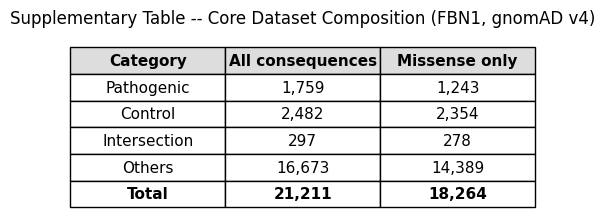

  -> Saved output\gemvap_notebook_gnomad4\Supplementary_Table_CoreDataset.png


In [4]:
step(4, "Render and save the supplementary table")
info("Writes a CSV (machine-readable) and a PNG (publication-style table figure).")

import matplotlib.pyplot as plt

csv_path = OUTPUT_DIR / "Supplementary_Table_CoreDataset.csv"
combined.to_csv(csv_path)
result(f"Saved {csv_path}")

fig, ax = plt.subplots(figsize=(6, 2.2))
ax.axis("off")

cell_text = [[cat, f"{combined.loc[cat, combined.columns[0]]:,}", f"{combined.loc[cat, combined.columns[1]]:,}"]
             for cat in combined.index]
col_labels = ["Category", "All consequences", "Missense only"]

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.6)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#dddddd")
    if row == len(cell_text):  # Total row
        cell.set_text_props(weight="bold")

ax.set_title("Supplementary Table -- Core Dataset Composition (FBN1, gnomAD v4)", pad=14, fontsize=12)

png_path = OUTPUT_DIR / "Supplementary_Table_CoreDataset.png"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

result(f"Saved {png_path}")

## Per-predictor ROC thresholds (GEMVAP 1, 2, 3)

This section answers a different question than the core-dataset composition
above: **when each GEMVAP sub-model is trained, every individual predictor
(SIFT, REVEL, MutPred2, CADD_raw, VEST4, MPC, PrimateAI,
phyloP100way_vertebrate, FATHMM_converted, GERP++_RS, ...) is re-thresholded
on the FBN1 training data.**

Concretely, for each candidate predictor, `roc_based_classification()`
(`packages/marfanlib/performance/classification.py`) runs a 10-fold
cross-validation ROC analysis and averages the 10 per-fold ROC-optimal
cutoffs into a single "case threshold" -- the score above which that
predictor alone calls a variant pathogenic (`direction = "greater"` for
every predictor). The GEMVAP consensus score is literally the count of
predictors whose score clears their own threshold, restricted to the
predictor panel selected for that model (`top_predictors`).

Each GEMVAP variant is trained -- and therefore re-thresholded -- on a
different subset of the training data:

| Model | Training subset | Panel size |
|---|---|---|
| GEMVAP_1 | All missense training variants (broadest / full training filter) | 12 |
| GEMVAP_2 | Non-cysteine variants only | 6 |
| GEMVAP_3 | Non-cysteine, outside conserved EGF-Ca2+ domain positions | 18 |

This is why GEMVAP_1/2/3 have different predictor panels *and* different
per-predictor thresholds even for predictors they share -- each threshold is
fit fresh on that model's own training subset.

These thresholds are not exported as CSV anywhere in the pipeline; they only
exist inside the cached `GEMVAP_{1,2,3}_fit.pkl` fit objects written by Part
1 (Steps 3-5), so this section reloads them directly.

In [5]:
step(5, "Per-predictor ROC thresholds for GEMVAP 1, 2, 3")
info("Reloading the cached fit objects from Part 1 (Steps 3-5) -- no retraining.\n"
     "Each fit stores rbc['threshold']['case']: a case threshold per candidate\n"
     "predictor, fitted via 10-fold ROC cross-validation on that model's own\n"
     "training subset -- plus top_predictors: the panel actually used for voting.")

import sys as _sys, types as _types
if "pandas.core.indexes.numeric" not in _sys.modules:
    # Compatibility shim: the cached .pkl fits were written under an older
    # pandas that stored integer indexes as pandas.core.indexes.numeric.Int64Index.
    # That module was removed in pandas 2.0+ (folded into the generic Index).
    # Aliasing it here lets pickle.load reconstruct those old indexes without
    # needing the exact pandas version the fits were originally produced with.
    _shim = _types.ModuleType("pandas.core.indexes.numeric")
    _shim.Int64Index = pd.Index
    _shim.Float64Index = pd.Index
    _shim.UInt64Index = pd.Index
    _sys.modules["pandas.core.indexes.numeric"] = _shim

from gemvap_pipeline.model import load_fit_result

MODEL_NAMES = ["GEMVAP_1", "GEMVAP_2", "GEMVAP_3"]
fits = {}
for name in MODEL_NAMES:
    fit_path = OUTPUT_DIR / f"{name}_fit.pkl"
    action(f"Loading {fit_path}")
    fits[name] = load_fit_result(fit_path)
    n_panel = len(fits[name]["top_predictors"])
    result(f"{name}: {n_panel} predictors in panel")

  Step 5 — Per-predictor ROC thresholds for GEMVAP 1, 2, 3
    [i] Reloading the cached fit objects from Part 1 (Steps 3-5) -- no retraining.
    [i] Each fit stores rbc['threshold']['case']: a case threshold per candidate
    [i] predictor, fitted via 10-fold ROC cross-validation on that model's own
    [i] training subset -- plus top_predictors: the panel actually used for voting.
  >> Loading output\gemvap_notebook_gnomad4\GEMVAP_1_fit.pkl
  -> GEMVAP_1: 12 predictors in panel
  >> Loading output\gemvap_notebook_gnomad4\GEMVAP_2_fit.pkl
  -> GEMVAP_2: 6 predictors in panel
  >> Loading output\gemvap_notebook_gnomad4\GEMVAP_3_fit.pkl
  -> GEMVAP_3: 18 predictors in panel


In [6]:
subsection("Per-model predictor panels, in KS-selection order")
action("Listing each model's selected predictors with their fitted case threshold")

per_model_tables = {}
for name in MODEL_NAMES:
    top_predictors = fits[name]["top_predictors"]
    thresholds = fits[name]["rbc"]["threshold"]["case"]
    rows = [
        (rank + 1, predictor, thresholds[predictor])
        for rank, predictor in enumerate(top_predictors)
    ]
    per_model_tables[name] = rows
    summary_table(
        f"{name} -- predictor panel and case thresholds",
        ["Rank", "Predictor", "Threshold"],
        [(r, p, f"{t:.4f}") for r, p, t in rows],
    )


  ----------------------------------------------------------------------
  Per-model predictor panels, in KS-selection order
  ----------------------------------------------------------------------
  >> Listing each model's selected predictors with their fitted case threshold

                   GEMVAP_1 -- predictor panel and case thresholds                   
Rank                    Predictor  Threshold
-------------------------------------------------------------------------------------
1      MutationAssessor_rankscore     0.7894
2               MetaSVM_rankscore     0.9435
3               MutPred_rankscore     0.8964
4                 M-CAP_rankscore     0.9566
5                 REVEL_rankscore     0.9344
6                MetaLR_rankscore     0.9460
7        SIFT_converted_rankscore     0.6655
8               DEOGEN2_rankscore     0.8472
9                 VEST4_rankscore     0.8425
10    PROVEAN_converted_rankscore     0.8400
11     Eigen-raw_coding_rankscore     0.8241
12     SI

In [7]:
subsection("Combined table: ALL 38 candidate predictors across GEMVAP 1, 2, 3")
info("Every candidate predictor gets a 10-fold ROC threshold fit for EACH model\n"
     "(38 candidates x 3 models = 114 thresholds total) -- but only a subset is\n"
     "then selected into that model's voting panel (top_predictors) by the\n"
     "KS-rank + incremental-F1 step. This table shows all 38, flagging which ones\n"
     "were selected for each model, not just the ones that made the cut somewhere.")

# Master predictor order = GEMVAP_1's KS ranking (GEMVAP_1 is the baseline /
# full-dataset model). All three models share the same 38 candidate predictors.
all_predictors = fits["GEMVAP_1"]["ordered_predictors_by_ks"]
assert set(all_predictors) == set(fits["GEMVAP_2"]["ordered_predictors_by_ks"])
assert set(all_predictors) == set(fits["GEMVAP_3"]["ordered_predictors_by_ks"])

combined_rows = []
for predictor in all_predictors:
    row = {"Predictor": predictor}
    for name in MODEL_NAMES:
        thresholds = fits[name]["rbc"]["threshold"]["case"]
        top_predictors = fits[name]["top_predictors"]
        row[f"{name}_threshold"] = thresholds[predictor]
        row[f"{name}_selected"] = predictor in top_predictors
    combined_rows.append(row)

combined_thresholds = pd.DataFrame(combined_rows).set_index("Predictor")
n_sel = {name: int(combined_thresholds[f"{name}_selected"].sum()) for name in MODEL_NAMES}
result(f"Combined table: {len(combined_thresholds)} candidate predictors "
       f"(selected -- GEMVAP_1: {n_sel['GEMVAP_1']}, GEMVAP_2: {n_sel['GEMVAP_2']}, "
       f"GEMVAP_3: {n_sel['GEMVAP_3']})")
display(combined_thresholds)


  ----------------------------------------------------------------------
  Combined table: ALL 38 candidate predictors across GEMVAP 1, 2, 3
  ----------------------------------------------------------------------
    [i] Every candidate predictor gets a 10-fold ROC threshold fit for EACH model
    [i] (38 candidates x 3 models = 114 thresholds total) -- but only a subset is
    [i] then selected into that model's voting panel (top_predictors) by the
    [i] KS-rank + incremental-F1 step. This table shows all 38, flagging which ones
    [i] were selected for each model, not just the ones that made the cut somewhere.
  -> Combined table: 38 candidate predictors (selected -- GEMVAP_1: 12, GEMVAP_2: 6, GEMVAP_3: 18)


,GEMVAP_1_threshold,GEMVAP_1_selected,GEMVAP_2_threshold,GEMVAP_2_selected,GEMVAP_3_threshold,GEMVAP_3_selected
Predictor,,,,,,
MutationAssessor_rankscore,0.789372,True,0.677047,True,0.418092,True
MetaSVM_rankscore,0.943503,True,0.920885,True,0.899563,True
MutPred_rankscore,0.896365,True,0.793085,True,0.755356,True
M-CAP_rankscore,0.956576,True,0.925482,False,0.895278,True
REVEL_rankscore,0.934356,True,0.908399,True,0.865030,True
MetaLR_rankscore,0.946031,True,0.935633,True,0.902242,True
SIFT_converted_rankscore,0.665466,True,0.596641,True,0.413003,True
DEOGEN2_rankscore,0.847151,True,0.813706,False,0.708253,True
VEST4_rankscore,0.842472,True,0.792236,False,0.678499,True



  ----------------------------------------------------------------------
  Saving the full threshold table
  ----------------------------------------------------------------------
  >> Writing CSV (all 38 x 3, with selected flags) and a table figure to OUTPUT_DIR
  -> Saved output\gemvap_notebook_gnomad4\Supplementary_Table_PredictorThresholds.csv


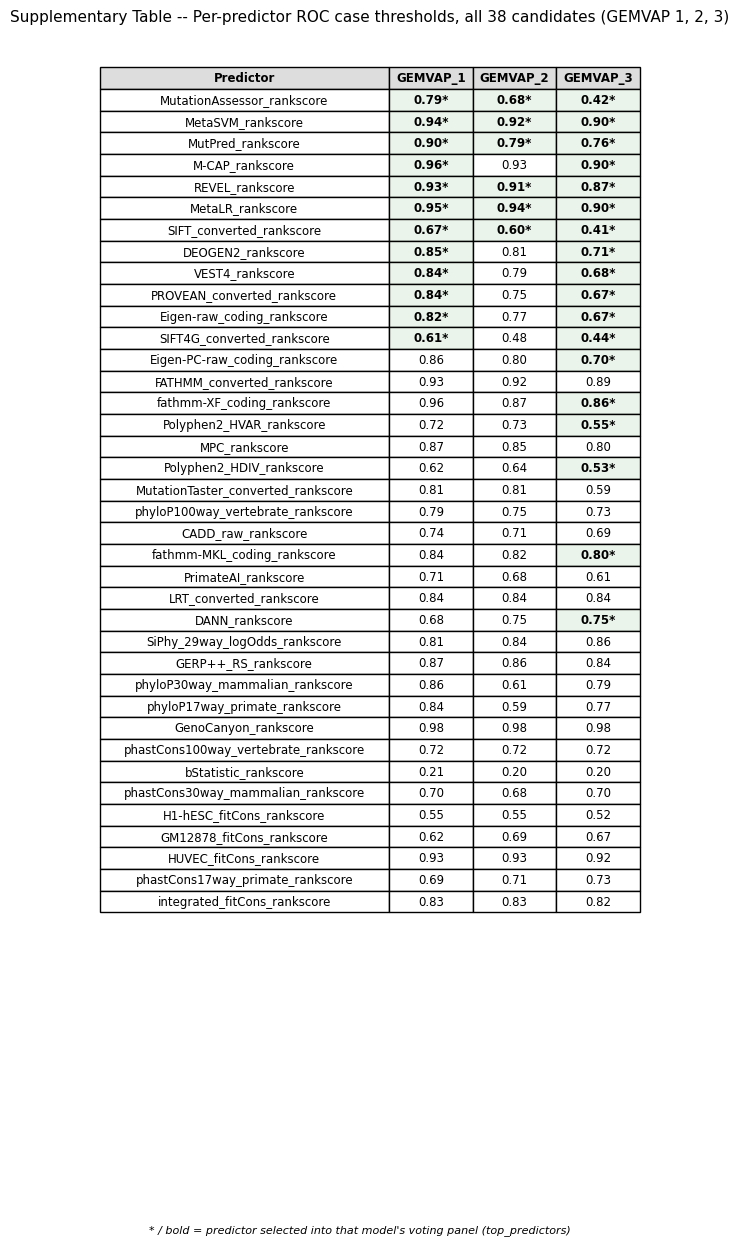

  -> Saved output\gemvap_notebook_gnomad4\Supplementary_Table_PredictorThresholds.png


In [8]:
subsection("Saving the full threshold table")
action("Writing CSV (all 38 x 3, with selected flags) and a table figure to OUTPUT_DIR")

csv_path = OUTPUT_DIR / "Supplementary_Table_PredictorThresholds.csv"
combined_thresholds.to_csv(csv_path)
result(f"Saved {csv_path}")

fig, ax = plt.subplots(figsize=(7.5, 0.32 * len(combined_thresholds) + 1.4))
ax.axis("off")

def _fmt(predictor, name):
    value = combined_thresholds.loc[predictor, f"{name}_threshold"]
    selected = combined_thresholds.loc[predictor, f"{name}_selected"]
    return f"{value:.2f}*" if selected else f"{value:.2f}"

cell_text = [
    [predictor] + [_fmt(predictor, name) for name in MODEL_NAMES]
    for predictor in combined_thresholds.index
]
col_labels = ["Predictor"] + MODEL_NAMES

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="center",
    loc="upper center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.3)
tbl.auto_set_column_width(col=list(range(len(col_labels))))

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#dddddd")
    elif col > 0:
        predictor = combined_thresholds.index[row - 1]
        name = MODEL_NAMES[col - 1]
        if combined_thresholds.loc[predictor, f"{name}_selected"]:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#eaf4ea")

ax.set_title(
    "Supplementary Table -- Per-predictor ROC case thresholds, all 38 candidates (GEMVAP 1, 2, 3)",
    pad=18, fontsize=11,
)
fig.text(
    0.5, 0.005,
    "* / bold = predictor selected into that model's voting panel (top_predictors)",
    ha="center", fontsize=8, style="italic",
)

png_path = OUTPUT_DIR / "Supplementary_Table_PredictorThresholds.png"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

result(f"Saved {png_path}")

## De novo pathogenic FBN1 missense variants in the test set

The Part 1 test set (Step 2) is built as: **all de novo pathogenic variants**
+ an equal number of controls (matched 1:1, selected by highest
`gnomAD_exomes_AN`). De novo variants were confirmed in index cases via NGS
and were never present in the historical pathogenic/control databases used
to train the individual predictors, so they give a leakage-free evaluation
set (see Part 1, Step 2 -- 66 de novo pathogenic variants reserved for
testing out of 132 total test-set variants).

This section extracts just that pathogenic half: the 66 de novo FBN1
missense variants, reloaded from the cached `test_dataset.csv` using the
same de novo override set (`_denovo_overrides.json`) Part 1 saved, so the
`is_case` / `is_denovo` flags are reconstructed identically to how the test
set was originally built.

In [9]:
step(6, "De novo pathogenic FBN1 missense variants in the test set")
info("Reloading test_dataset.csv with the saved de novo override set, so is_case /\n"
     "is_denovo are reconstructed exactly as in Part 1, Step 2 -- then filtering to\n"
     "variants that are BOTH de novo AND pathogenic: the test set's pathogenic half.")

from gemvap_pipeline.data import load_cached_datasets, load_denovo_overrides

action("Reloading cached train/test split")
denovo_overrides = load_denovo_overrides(OUTPUT_DIR)
_, df_test = load_cached_datasets(
    OUTPUT_DIR, DATA_PATH, seed=SEED, pathogenic_overrides=denovo_overrides,
)

denovo_case_mask = df_test.is_denovo & df_test.is_case
n_denovo_case = int(denovo_case_mask.sum())
result(f"{n_denovo_case} de novo pathogenic variants found in the test set")

  Step 6 — De novo pathogenic FBN1 missense variants in the test set
    [i] Reloading test_dataset.csv with the saved de novo override set, so is_case /
    [i] is_denovo are reconstructed exactly as in Part 1, Step 2 -- then filtering to
    [i] variants that are BOTH de novo AND pathogenic: the test set's pathogenic half.
  >> Reloading cached train/test split


C:\Users\Admin\Desktop\PhD\VSC_2\gemvap_clean_pipeline\gemvap_pipeline\data.py:332: DtypeWarning: Columns (0: aapos, 1: Uniprot_acc, 2: Uniprot_entry, 3: TSL_x, 4: SIFT_score, 5: SIFT4G_score, 6: Polyphen2_HDIV_score, 7: Polyphen2_HDIV_pred, 8: Polyphen2_HVAR_score, 9: Polyphen2_HVAR_pred, 10: MutationTaster_score, 11: MutationAssessor_score, 12: MutationAssessor_pred, 13: FATHMM_score, 14: PROVEAN_score, 15: VEST4_score, 16: MVP_score, 17: MPC_score, 18: DEOGEN2_score, 19: DEOGEN2_pred, 20: Aloft_Fraction_transcripts_affected, 21: Aloft_prob_Tolerant, 22: Aloft_prob_Recessive, 23: Aloft_prob_Dominant, 24: Aloft_pred, 25: Aloft_Confidence, 26: clinvar_var_source, 27: clinvar_OMIM_id, 28: Interpro_domain) have mixed types. Specify dtype option on import or set low_memory=False.
  dp.data = pd.read_csv(csv_path)


  -> 66 de novo pathogenic variants found in the test set


In [10]:
subsection("Building the variant table")
action("Selecting identifying columns and sorting by protein position")

denovo_pathogenic = df_test.data.loc[denovo_case_mask, [
    "cDNA", "HGVSp_VEP", "aaref", "aapos", "aaalt", "EXON",
    "#chr", "pos(1-based)", "ref", "alt",
]].copy()
denovo_pathogenic["Cysteine_variant"] = df_test.is_cys.loc[denovo_case_mask].values
denovo_pathogenic["aapos"] = pd.to_numeric(denovo_pathogenic["aapos"], errors="coerce")
denovo_pathogenic = denovo_pathogenic.sort_values("aapos").reset_index(drop=True)
denovo_pathogenic.columns = [
    "cDNA", "Protein change", "Ref AA", "Position", "Alt AA", "Exon",
    "Chr", "Genomic pos (hg38)", "Ref allele", "Alt allele", "Cysteine variant",
]

n_cys = int(denovo_pathogenic["Cysteine variant"].sum())
result(f"{len(denovo_pathogenic)} variants  |  {n_cys} cysteine  |  "
       f"{len(denovo_pathogenic) - n_cys} non-cysteine")
display(denovo_pathogenic)


  ----------------------------------------------------------------------
  Building the variant table
  ----------------------------------------------------------------------
  >> Selecting identifying columns and sorting by protein position
  -> 66 variants  |  50 cysteine  |  16 non-cysteine


,cDNA,Protein change,Ref AA,Position,Alt AA,Exon,Chr,Genomic pos (hg38),Ref allele,Alt allele,Cysteine variant
0,c.200G>C,p.Cys67Ser,C,67,S,3/66,15,48613057,C,G,True
1,c.407G>T,p.Cys136Phe,C,136,F,5/66,15,48600174,C,A,True
2,c.460T>C,p.Cys154Arg,C,154,R,6/66,15,48596361,A,G,True
3,c.641G>A,p.Gly214Asp,G,214,D,7/66,15,48537706,C,T,False
4,c.1079G>A,p.Cys360Tyr,C,360,Y,10/66,15,48520727,C,T,True
...,...,...,...,...,...,...,...,...,...,...,...
61,c.7775G>T,p.Cys2592Phe,C,2592,F,63/66,15,48420731,C,A,True
62,c.7865G>A,p.Cys2622Tyr,C,2622,Y,64/66,15,48415722,C,T,True
63,c.8444T>G,p.Leu2815Arg,L,2815,R,66/66,15,48411162,A,C,False
64,c.8447A>C,p.His2816Pro,H,2816,P,66/66,15,48411159,T,G,False



  ----------------------------------------------------------------------
  Saving the de novo pathogenic variant table
  ----------------------------------------------------------------------
  >> Writing CSV and a table figure to OUTPUT_DIR
  -> Saved output\gemvap_notebook_gnomad4\Supplementary_Table_DenovoPathogenicVariants.csv


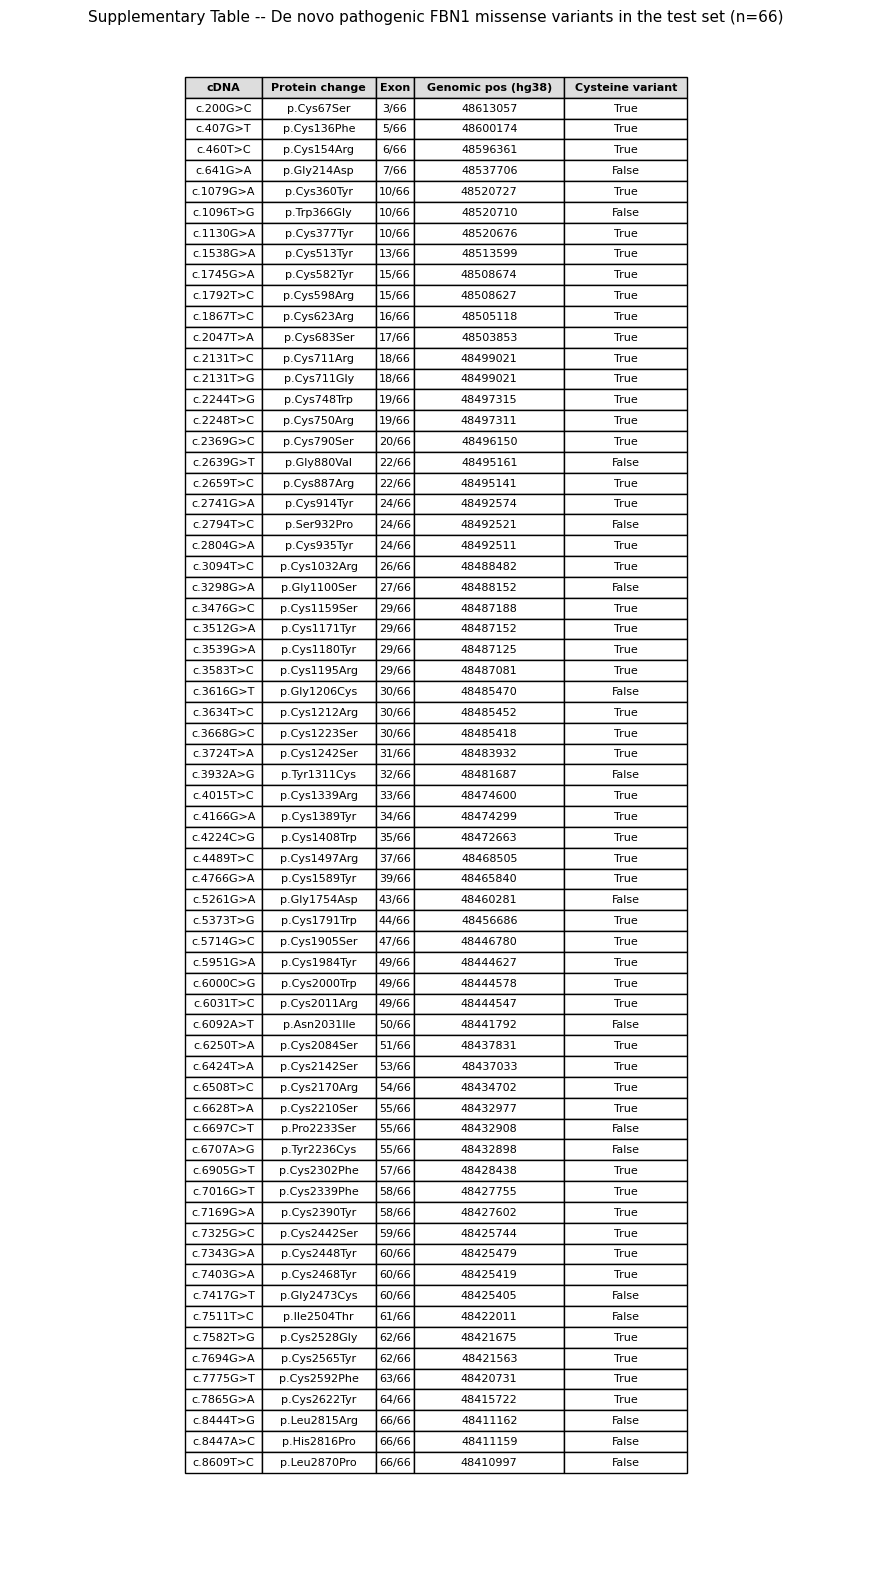

  -> Saved output\gemvap_notebook_gnomad4\Supplementary_Table_DenovoPathogenicVariants.png


In [11]:
subsection("Saving the de novo pathogenic variant table")
action("Writing CSV and a table figure to OUTPUT_DIR")

csv_path = OUTPUT_DIR / "Supplementary_Table_DenovoPathogenicVariants.csv"
denovo_pathogenic.to_csv(csv_path, index=False)
result(f"Saved {csv_path}")

fig, ax = plt.subplots(figsize=(11, 0.28 * len(denovo_pathogenic) + 1.2))
ax.axis("off")

display_cols = ["cDNA", "Protein change", "Exon", "Genomic pos (hg38)", "Cysteine variant"]
cell_text = denovo_pathogenic[display_cols].astype(str).values.tolist()

tbl = ax.table(
    cellText=cell_text,
    colLabels=display_cols,
    cellLoc="center",
    loc="upper center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.25)
tbl.auto_set_column_width(col=list(range(len(display_cols))))

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#dddddd")

ax.set_title(
    f"Supplementary Table -- De novo pathogenic FBN1 missense variants in the test set (n={len(denovo_pathogenic)})",
    pad=18, fontsize=11,
)

png_path = OUTPUT_DIR / "Supplementary_Table_DenovoPathogenicVariants.png"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

result(f"Saved {png_path}")

## Training dataset composition per GEMVAP model

Each GEMVAP model is fit on a different subset of the Part 1 training set
(`training_dataset.csv`): GEMVAP_1 uses it in full, GEMVAP_2 drops cysteine
variants, and GEMVAP_3 additionally drops conserved-domain positions (see the
per-predictor threshold section above). This table reports, for each model's
own training subset -- reconstructed from `fits[name]["training_data"]`
(cached inside the `.pkl` fit, reused from Step 5 above) -- the number of
pathogenic and control variants actually trained on, and the size of that
model's selected predictor panel.

In [12]:
step(7, "Training dataset composition per GEMVAP model")
info("Re-deriving is_case/is_ctrl on each model's own training_data (already cached\n"
     "inside fits[name] from Step 5) via the same DataProcessor.create_filters()\n"
     "logic used during training -- not re-reading the raw table.")

from packages.package1.predictor_selection import DataProcessor

composition_rows = []
for name in MODEL_NAMES:
    dp = DataProcessor(DATA_PATH, seed=SEED)
    dp.data = fits[name]["training_data"]
    dp.create_filters()
    n_path = int(dp.is_case.sum())
    n_ctrl = int(dp.is_ctrl.sum())
    n_total = len(dp.data)
    n_pred = len(fits[name]["top_predictors"])
    composition_rows.append((name, n_path, n_ctrl, n_total, n_pred))

summary_table(
    "GEMVAP training dataset composition",
    ["Model", "Pathogenic", "Control", "Total", "Predictors used"],
    composition_rows,
)

training_composition = pd.DataFrame(
    composition_rows,
    columns=["Model", "Pathogenic", "Control", "Total", "Predictors used"],
).set_index("Model")
display(training_composition)

  Step 7 — Training dataset composition per GEMVAP model
    [i] Re-deriving is_case/is_ctrl on each model's own training_data (already cached
    [i] inside fits[name] from Step 5) via the same DataProcessor.create_filters()
    [i] logic used during training -- not re-reading the raw table.



                         GEMVAP training dataset composition                         
Model     Pathogenic  Control  Total  Predictors used
-------------------------------------------------------------------------------------
GEMVAP_1         367     1721   2088               12
GEMVAP_2         170     1694   1864                6
GEMVAP_3          81     1444   1525               18


,Pathogenic,Control,Total,Predictors used
Model,,,,
GEMVAP_1,367,1721,2088,12
GEMVAP_2,170,1694,1864,6
GEMVAP_3,81,1444,1525,18



  ----------------------------------------------------------------------
  Saving the training composition table
  ----------------------------------------------------------------------
  >> Writing CSV and a table figure to OUTPUT_DIR
  -> Saved output\gemvap_notebook_gnomad4\Supplementary_Table_TrainingComposition.csv


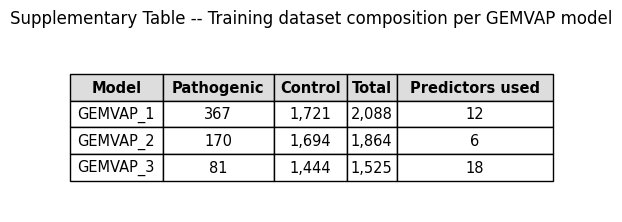

  -> Saved output\gemvap_notebook_gnomad4\Supplementary_Table_TrainingComposition.png


In [13]:
subsection("Saving the training composition table")
action("Writing CSV and a table figure to OUTPUT_DIR")

csv_path = OUTPUT_DIR / "Supplementary_Table_TrainingComposition.csv"
training_composition.to_csv(csv_path)
result(f"Saved {csv_path}")

fig, ax = plt.subplots(figsize=(6.5, 2.2))
ax.axis("off")

cell_text = [
    [model] + [f"{training_composition.loc[model, col]:,}" for col in training_composition.columns]
    for model in training_composition.index
]
col_labels = ["Model"] + list(training_composition.columns)

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10.5)
tbl.scale(1, 1.6)
tbl.auto_set_column_width(col=list(range(len(col_labels))))

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#dddddd")

ax.set_title(
    "Supplementary Table -- Training dataset composition per GEMVAP model",
    pad=14, fontsize=12,
)

png_path = OUTPUT_DIR / "Supplementary_Table_TrainingComposition.png"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

result(f"Saved {png_path}")

## Predicted-pathogenic counts on the training set

For each model, how many of its own training-set pathogenic variants does
GEMVAP itself call pathogenic? "Predicted pathogenic" uses the same
definition the pipeline uses everywhere else it reports F1/accuracy (Step 6
above, and Part 1's own test-set metrics): a variant's consensus score is
recomputed with that model's own selected predictor panel and per-predictor
thresholds (`apply_consensus_score`, reusing `fits[name]` from Step 5), then
compared against the **calibrated PP3_Supporting threshold** from
`calibration/{name}_thresholds.csv` (`gemvap_pejaver_calibration.annotate_variant`
uses `score >= PP3_Supporting` as the pathogenic call). Scores between
BP4_Supporting and PP3_Supporting are VUS (indeterminate, no evidence
either way) rather than a clear miss.

Note these numbers will generally look lower than the test-set F1/recall
reported earlier: the training pathogenic pool (HGMD/UMD/FRANKEN/MUTDB/PARIS/GENT)
is far more heterogeneous than the test set's de novo pathogenic pool, which
is dominated by cysteine variants (50/66, see the de novo table above) --
FBN1's easiest class to classify correctly.

In [14]:
step(8, "Predicted-pathogenic counts on the training set")
info("Re-scoring each model's own training_data with its own top_predictors +\n"
     "per-predictor thresholds (apply_consensus_score), then classifying against\n"
     "the calibrated PP3_Supporting threshold from Step 6 -- score >= threshold\n"
     "counts as 'predicted pathogenic', matching annotate_variant()'s own rule.")

from gemvap_pipeline.model import apply_consensus_score
from gemvap_pejaver_calibration import annotate_variant

pp3_supporting = {}
bp4_supporting = {}
for name in MODEL_NAMES:
    thr = pd.read_csv(OUTPUT_DIR / "calibration" / f"{name}_thresholds.csv")
    thr = thr.set_index("evidence_level")["score_threshold"]
    pp3_supporting[name] = thr["PP3_Supporting"]
    bp4_supporting[name] = thr["BP4_Supporting"]

predicted_rows = []
for name in MODEL_NAMES:
    dp = DataProcessor(DATA_PATH, seed=SEED)
    dp.data = fits[name]["training_data"]
    dp.create_filters()

    scores = apply_consensus_score(dp.data, fits[name]["top_predictors"], fits[name]["rbc"]["threshold"]["case"])
    path_scores = scores[dp.is_case]
    pp3, bp4 = pp3_supporting[name], bp4_supporting[name]

    n_total = len(path_scores)
    n_pred_path = int((path_scores >= pp3).sum())
    n_vus = int(((path_scores > bp4) & (path_scores < pp3)).sum())
    n_pred_benign = int((path_scores <= bp4).sum())
    predicted_rows.append((name, n_total, n_pred_path, n_vus, n_pred_benign))

predicted_pathogenic = pd.DataFrame(
    predicted_rows,
    columns=["Model", "Pathogenic (training)", "Predicted pathogenic", "VUS (indeterminate)", "Predicted benign"],
).set_index("Model")
predicted_pathogenic["% predicted pathogenic"] = (
    100 * predicted_pathogenic["Predicted pathogenic"] / predicted_pathogenic["Pathogenic (training)"]
).round(1)

summary_table(
    "Predicted-pathogenic counts on the training set",
    list(predicted_pathogenic.reset_index().columns),
    [tuple(r) for r in predicted_pathogenic.reset_index().itertuples(index=False)],
)
display(predicted_pathogenic)

  Step 8 — Predicted-pathogenic counts on the training set
    [i] Re-scoring each model's own training_data with its own top_predictors +
    [i] per-predictor thresholds (apply_consensus_score), then classifying against
    [i] the calibrated PP3_Supporting threshold from Step 6 -- score >= threshold
    [i] counts as 'predicted pathogenic', matching annotate_variant()'s own rule.



                                  Predicted-pathogenic counts on the training set                                   
Model     Pathogenic (training)  Predicted pathogenic  VUS (indeterminate)  Predicted benign  % predicted pathogenic
--------------------------------------------------------------------------------------------------------------------
GEMVAP_1                    367                   248                   63                56                    67.6
GEMVAP_2                    170                    91                   19                60                    53.5
GEMVAP_3                     81                    23                   27                31                    28.4


,Pathogenic (training),Predicted pathogenic,VUS (indeterminate),Predicted benign,% predicted pathogenic
Model,,,,,
GEMVAP_1,367,248,63,56,67.6
GEMVAP_2,170,91,19,60,53.5
GEMVAP_3,81,23,27,31,28.4


In [15]:
subsection("Saving the predicted-pathogenic table")
action("Writing CSV and a table figure to OUTPUT_DIR")

csv_path = OUTPUT_DIR / "Supplementary_Table_PredictedPathogenic.csv"
predicted_pathogenic.to_csv(csv_path)
result(f"Saved {csv_path}")

fig, ax = plt.subplots(figsize=(9, 2.2))
ax.axis("off")

cols = list(predicted_pathogenic.columns)
cell_text = [
    [model] + [
        f"{predicted_pathogenic.loc[model, c]:,}" if c != "% predicted pathogenic"
        else f"{predicted_pathogenic.loc[model, c]:.1f}%"
        for c in cols
    ]
    for model in predicted_pathogenic.index
]
col_labels = ["Model"] + cols

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.6)
tbl.auto_set_column_width(col=list(range(len(col_labels))))

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#dddddd")

ax.set_title(
    "Supplementary Table -- Predicted-pathogenic counts on the training set (GEMVAP 1, 2, 3)",
    pad=14, fontsize=11,
)

png_path = OUTPUT_DIR / "Supplementary_Table_PredictedPathogenic.png"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

result(f"Saved {png_path}")


  ----------------------------------------------------------------------
  Saving the predicted-pathogenic table
  ----------------------------------------------------------------------
  >> Writing CSV and a table figure to OUTPUT_DIR
  -> Saved output\gemvap_notebook_gnomad4\Supplementary_Table_PredictedPathogenic.csv
  -> Saved output\gemvap_notebook_gnomad4\Supplementary_Table_PredictedPathogenic.png


C:\Users\Admin\AppData\Local\Temp\ipykernel_28148\2807985481.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Predicted-pathogenic counts against the FULL training set

Step 8 scored each model against its **own** training subset (GEMVAP_2 on
170 non-cysteine pathogenic variants, GEMVAP_3 on 81 non-cysteine/non-domain
pathogenic variants). This section instead scores **all three models against
the same full 367-pathogenic training pool GEMVAP_1 uses** -- i.e. GEMVAP_2's
and GEMVAP_3's own predictor panel + thresholds are applied to variants they
were never trained on (cysteine variants for GEMVAP_2; cysteine + conserved-domain
variants for GEMVAP_3), so the three models become directly comparable on one
common denominator.

Same classification rule as Step 8: each model's own consensus score
(`apply_consensus_score` with that model's `top_predictors` +
`rbc["threshold"]["case"]`) compared against that model's own calibrated
PP3_Supporting / BP4_Supporting thresholds.

In [16]:
step(9, "Predicted-pathogenic counts against the full training set")
info("Reusing GEMVAP_1's training_data (the full 367-pathogenic / 1721-control\n"
     "training set) as a common denominator, and re-scoring it with EACH model's\n"
     "own predictor panel + thresholds -- including GEMVAP_2/3 on variants (cysteine,\n"
     "conserved-domain) they were not trained on.")

full_dp = DataProcessor(DATA_PATH, seed=SEED)
full_dp.data = fits["GEMVAP_1"]["training_data"]
full_dp.create_filters()
n_full_path = int(full_dp.is_case.sum())
result(f"Full training set: {len(full_dp.data)} variants  |  {n_full_path} pathogenic  |  "
       f"{int(full_dp.is_ctrl.sum())} control")

full_predicted_rows = []
for name in MODEL_NAMES:
    scores = apply_consensus_score(full_dp.data, fits[name]["top_predictors"], fits[name]["rbc"]["threshold"]["case"])
    path_scores = scores[full_dp.is_case]
    pp3, bp4 = pp3_supporting[name], bp4_supporting[name]

    n_pred_path = int((path_scores >= pp3).sum())
    n_vus = int(((path_scores > bp4) & (path_scores < pp3)).sum())
    n_pred_benign = int((path_scores <= bp4).sum())
    full_predicted_rows.append((name, n_full_path, n_pred_path, n_vus, n_pred_benign))

full_predicted_pathogenic = pd.DataFrame(
    full_predicted_rows,
    columns=["Model", "Pathogenic (full training set)", "Predicted pathogenic", "VUS (indeterminate)", "Predicted benign"],
).set_index("Model")
full_predicted_pathogenic["% predicted pathogenic"] = (
    100 * full_predicted_pathogenic["Predicted pathogenic"] / full_predicted_pathogenic["Pathogenic (full training set)"]
).round(1)

summary_table(
    "Predicted-pathogenic counts against the full training set",
    list(full_predicted_pathogenic.reset_index().columns),
    [tuple(r) for r in full_predicted_pathogenic.reset_index().itertuples(index=False)],
)
display(full_predicted_pathogenic)

  Step 9 — Predicted-pathogenic counts against the full training set
    [i] Reusing GEMVAP_1's training_data (the full 367-pathogenic / 1721-control
    [i] training set) as a common denominator, and re-scoring it with EACH model's
    [i] own predictor panel + thresholds -- including GEMVAP_2/3 on variants (cysteine,
    [i] conserved-domain) they were not trained on.
  -> Full training set: 2088 variants  |  367 pathogenic  |  1721 control



                                  Predicted-pathogenic counts against the full training set                                  
Model     Pathogenic (full training set)  Predicted pathogenic  VUS (indeterminate)  Predicted benign  % predicted pathogenic
-----------------------------------------------------------------------------------------------------------------------------
GEMVAP_1                             367                   248                   63                56                    67.6
GEMVAP_2                             367                   278                   27                62                    75.7
GEMVAP_3                             367                   247                   88                32                    67.3


,Pathogenic (full training set),Predicted pathogenic,VUS (indeterminate),Predicted benign,% predicted pathogenic
Model,,,,,
GEMVAP_1,367,248,63,56,67.6
GEMVAP_2,367,278,27,62,75.7
GEMVAP_3,367,247,88,32,67.3


In [17]:
subsection("Saving the full-training-set predicted-pathogenic table")
action("Writing CSV and a table figure to OUTPUT_DIR")

csv_path = OUTPUT_DIR / "Supplementary_Table_PredictedPathogenic_FullTrainingSet.csv"
full_predicted_pathogenic.to_csv(csv_path)
result(f"Saved {csv_path}")

fig, ax = plt.subplots(figsize=(9.5, 2.2))
ax.axis("off")

cols = list(full_predicted_pathogenic.columns)
cell_text = [
    [model] + [
        f"{full_predicted_pathogenic.loc[model, c]:,}" if c != "% predicted pathogenic"
        else f"{full_predicted_pathogenic.loc[model, c]:.1f}%"
        for c in cols
    ]
    for model in full_predicted_pathogenic.index
]
col_labels = ["Model"] + cols

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.6)
tbl.auto_set_column_width(col=list(range(len(col_labels))))

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#dddddd")

ax.set_title(
    "Supplementary Table -- Predicted-pathogenic counts, all models vs. the full training set",
    pad=14, fontsize=11,
)

png_path = OUTPUT_DIR / "Supplementary_Table_PredictedPathogenic_FullTrainingSet.png"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

result(f"Saved {png_path}")


  ----------------------------------------------------------------------
  Saving the full-training-set predicted-pathogenic table
  ----------------------------------------------------------------------
  >> Writing CSV and a table figure to OUTPUT_DIR
  -> Saved output\gemvap_notebook_gnomad4\Supplementary_Table_PredictedPathogenic_FullTrainingSet.csv
  -> Saved output\gemvap_notebook_gnomad4\Supplementary_Table_PredictedPathogenic_FullTrainingSet.png


C:\Users\Admin\AppData\Local\Temp\ipykernel_28148\304087964.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
